# Fama-French 49 industry portfolios

This example downloads Kenneth French's 49 industry portfolio returns through `pandas-datareader`, then applies the second- and higher-order factor estimators. Internet access is required when the notebook runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as web

import pyhofa


In [2]:
ff = web.DataReader(
    "49_Industry_Portfolios",
    "famafrench",
    start="1990-01-01",
)[0]

# The French library encodes missing observations with large negative sentinels.
returns = ff.replace({-99.99: np.nan, -999.0: np.nan}).astype(float) / 100.0
returns = returns.dropna(axis=1, how="any").dropna(axis=0, how="any")
returns.index = returns.index.to_timestamp("M")
returns.tail()


,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-28,0.0935,0.0515,0.0881,0.0899,0.0611,0.0111,0.1153,-0.0252,0.0864,0.0541,...,0.0797,0.0346,0.0553,-0.0360,0.0620,-0.0429,-0.0156,-0.1042,-0.0745,0.0579
2026-03-31,0.0329,-0.0889,-0.0857,-0.0808,-0.0863,-0.0925,-0.0187,0.0590,-0.1428,-0.1146,...,-0.1082,-0.0689,-0.0914,-0.0295,-0.0765,-0.0253,-0.0543,-0.0824,-0.0337,-0.0575
2026-04-30,-0.0298,0.0058,0.0416,0.0322,0.0288,0.0541,-0.0072,0.0177,0.0198,-0.0307,...,-0.0051,0.0772,0.0442,0.1375,0.0484,0.0840,0.1178,0.0664,0.0841,-0.0122
2026-05-31,-0.0320,-0.0087,0.0227,-0.0745,0.0370,-0.0135,-0.0454,-0.0284,-0.0116,0.0248,...,-0.0248,0.0160,-0.0365,-0.0267,-0.0279,-0.0228,-0.0117,-0.0658,0.0254,0.0058
2026-06-30,0.0836,-0.0154,0.0420,-0.0200,0.0345,0.0270,-0.0940,-0.0306,0.0368,-0.0487,...,0.1327,0.0395,0.0689,-0.0559,0.0214,0.0833,0.0855,0.1071,-0.0307,0.0402


In [3]:
window = returns.tail(360)
X = window.to_numpy()

selection = pd.Series({
    "ER": pyhofa.m2_select(X, method="ER", rmax=8).R,
    "GR": pyhofa.m2_select(X, method="GR", rmax=8).R,
    "GER3": pyhofa.m3_select(X, method="GER3", rmax=8).R,
    "GER4": pyhofa.m4_select(X, method="GER4", rmax=8).R,
})
selection


ER      1
GR      1
GER3    5
GER4    1
dtype: int64

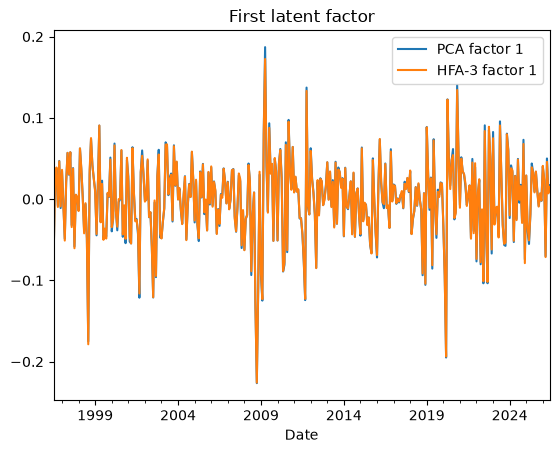

In [4]:
r = max(1, min(5, int(selection["GER3"])))
pca = pyhofa.m2_pca(X, r=r)
hfa = pyhofa.m3_als(X, rh=r, rg=0)

factors = pd.DataFrame(
    np.column_stack([pca.factors[:, 0], hfa.factors[:, 0]]),
    index=window.index,
    columns=["PCA factor 1", "HFA-3 factor 1"],
)
factors.plot(title="First latent factor")
plt.show()


In [5]:
adaptive = pyhofa.adaptive_hfa(X, r=r, max_order=3)
{
    "factor_order": adaptive.cumulant_order_f,
    "loading_order": adaptive.cumulant_order_u,
    "FCR": adaptive.factor_contribution_ratios,
}


{'factor_order': 3,
 'loading_order': 3,
 'FCR': {2: 0.7675324251301823, 3: 0.9789481205602562}}

For empirical work, decide transformations, standardization, the estimation window, and factor count based on the intended econometric specification rather than treating these defaults as universal.
